Loading review sample...
Loaded 50000 reviews
Loading metadata...
Loaded 24620 metadata records


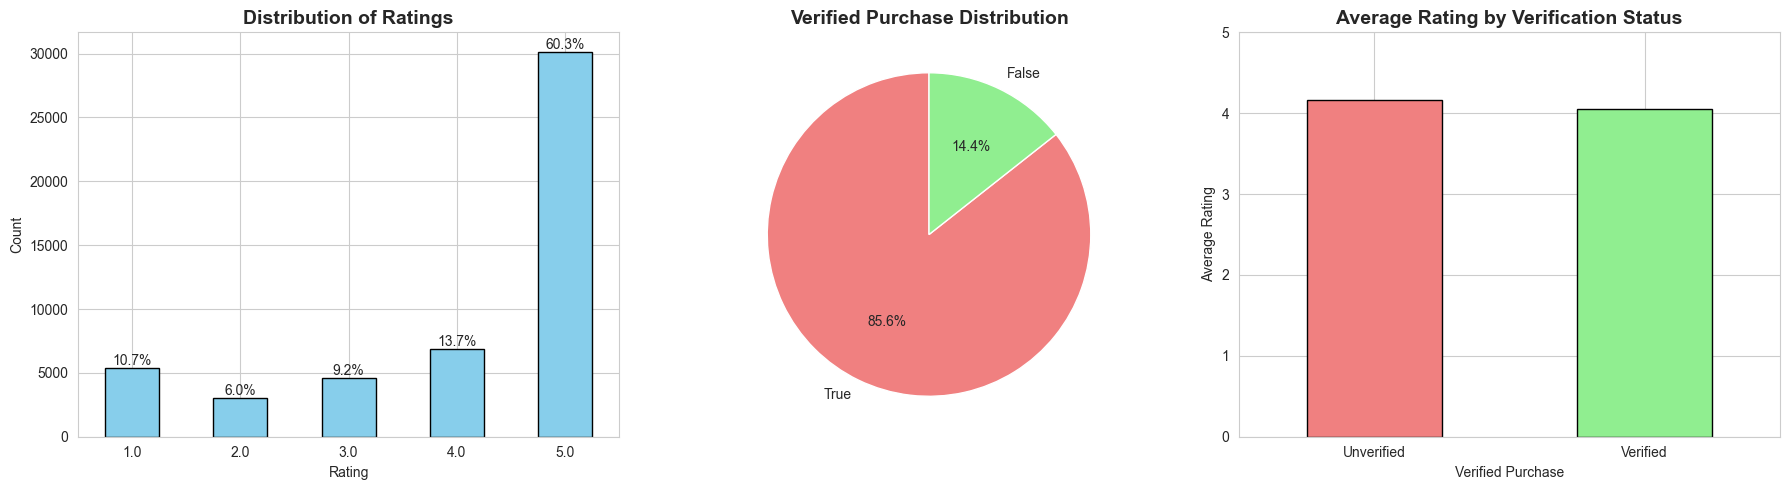


RATING STATISTICS
Mean Rating: 4.07
Median Rating: 5.00
Std Dev: 1.38

Verified Purchases: 85.6%


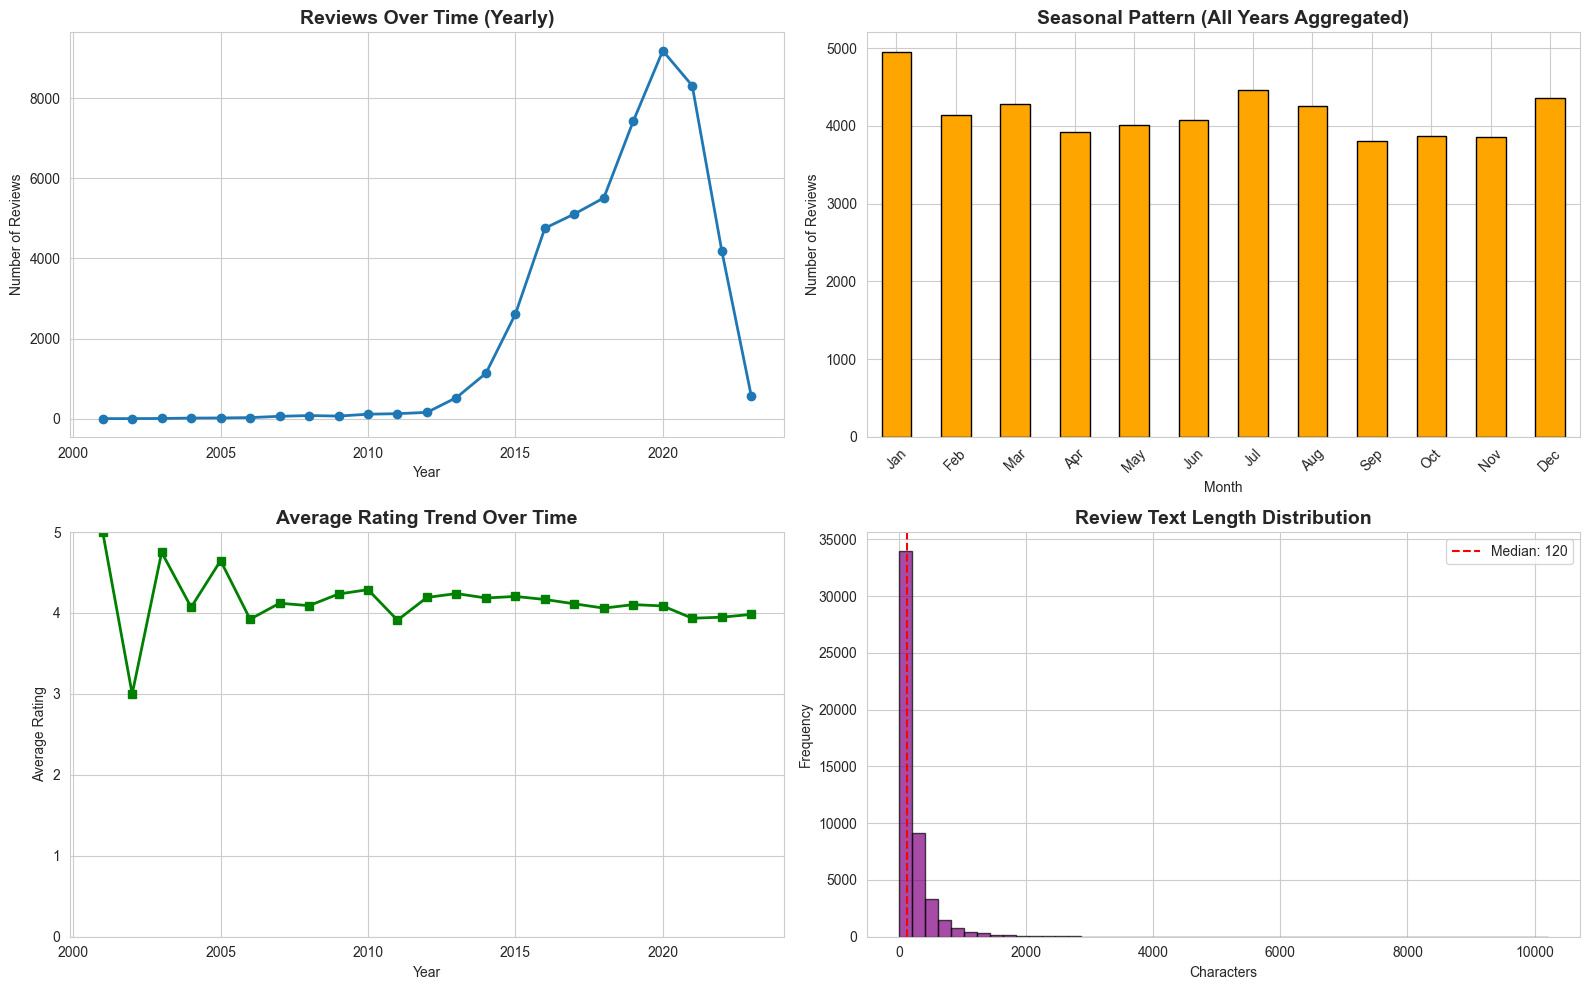


TEMPORAL STATISTICS
Date Range: 2001-03-05 07:27:57 to 2023-03-21 00:44:31.712000
Median Review Length: 120 characters
Mean Review Length: 219 characters


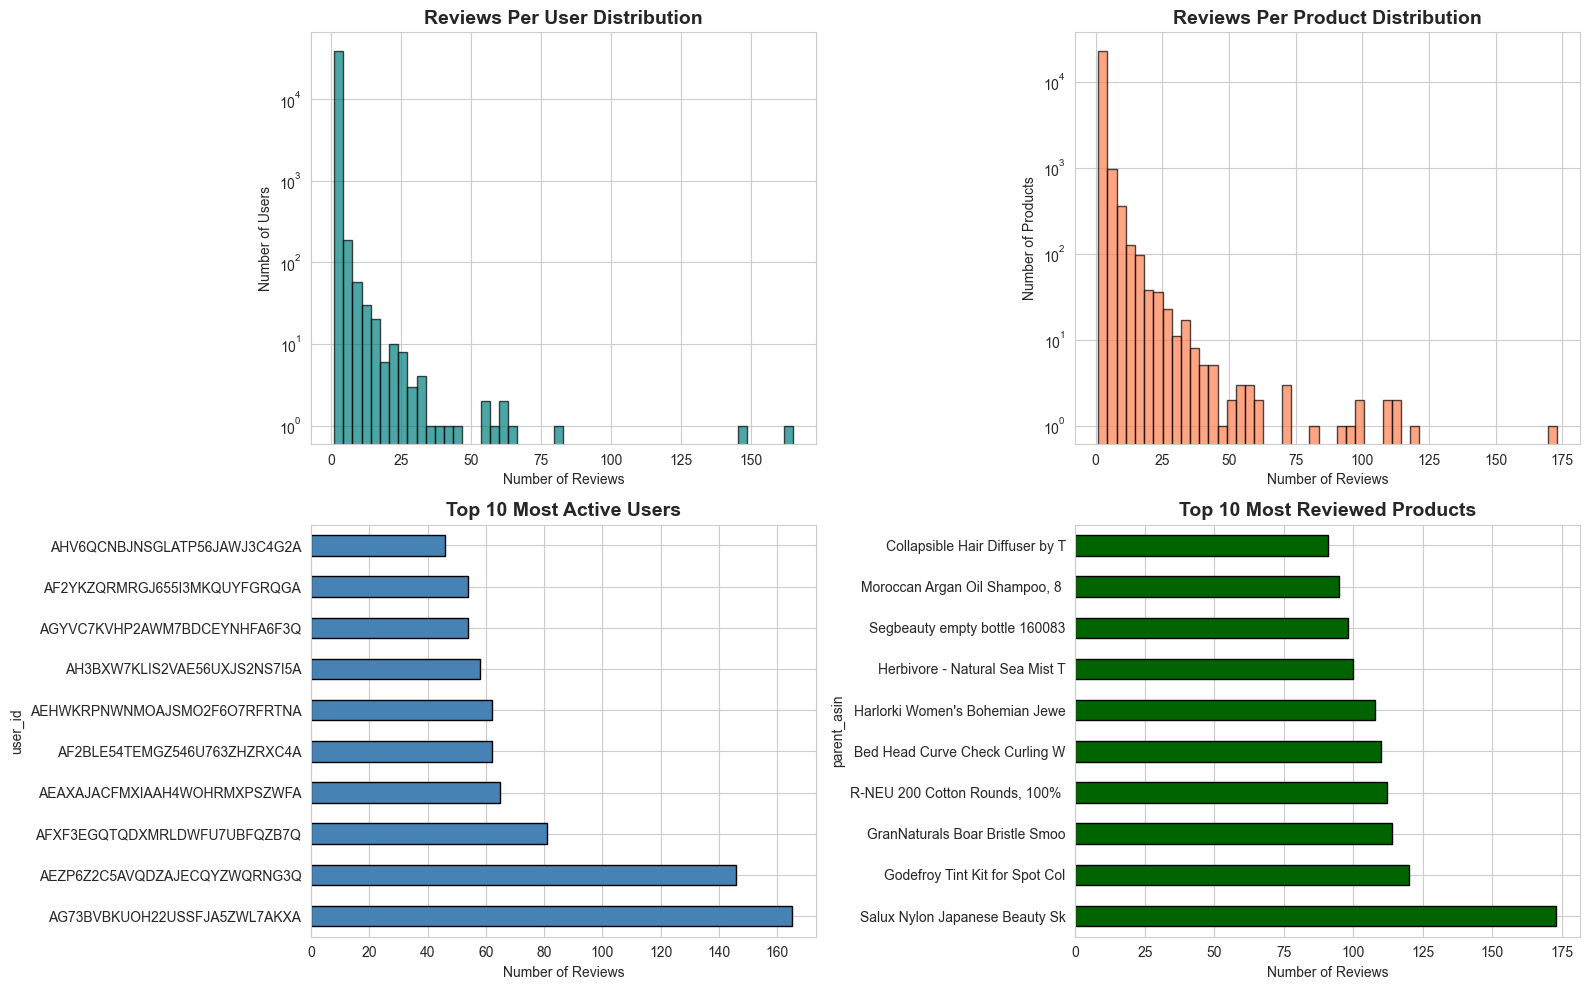


USER & PRODUCT STATISTICS
Unique Users: 39,619
Unique Products: 24,620
Reviews per User (median): 1.0
Reviews per User (mean): 1.3
Reviews per Product (median): 1.0
Reviews per Product (mean): 2.0


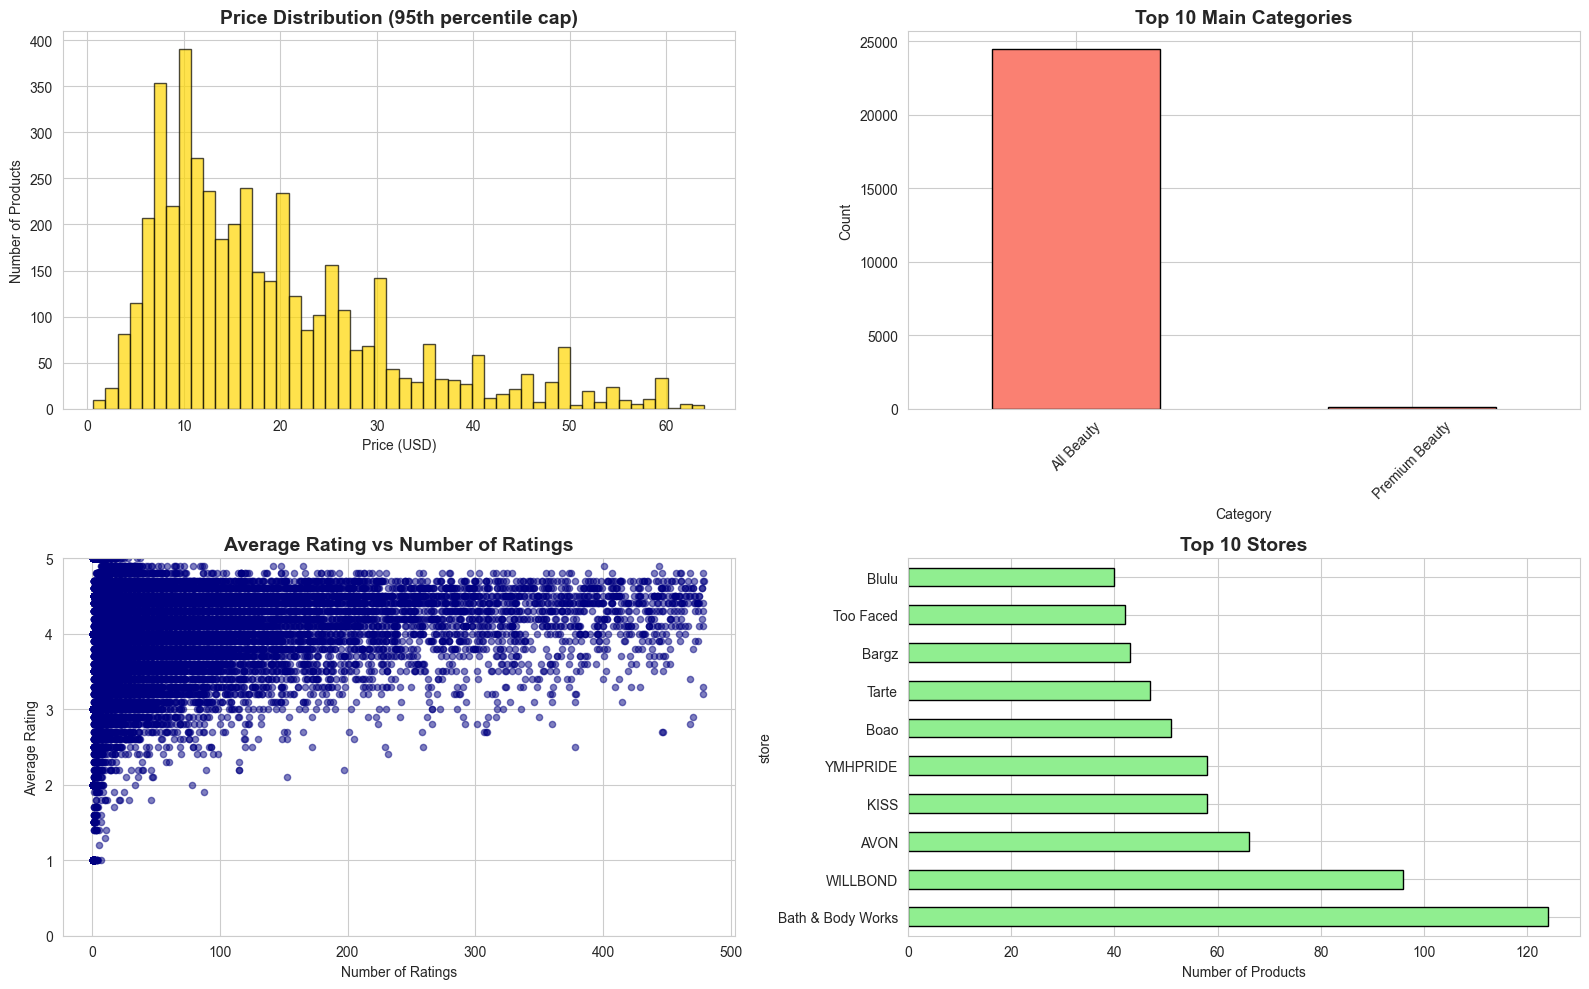


METADATA STATISTICS
Products with Metadata: 24,620
Price Statistics (USD):
  Mean: $18.91
  Median: $15.16
  Min: $0.59
  Max: $63.96

AMAZON REVIEWS 2023 - EDA SUMMARY REPORT
Category: C:\Users\hafil\OneDrive\Documents\SCC 454\scc454_amazon_project\data\raw\All_Beauty
Sample Size: 50,000 reviews

1. OVERVIEW
   - Total Reviews in Sample: 50,000
   - Unique Users: 39,619
   - Unique Products: 24,620
   - Date Range: 2001-03-05 to 2023-03-21

2. RATINGS
   - Mean Rating: 4.07/5.0
   - Rating Distribution: {1.0: np.int64(5355), 2.0: np.int64(3013), 3.0: np.int64(4598), 4.0: np.int64(6874), 5.0: np.int64(30160)}
   - Verified Purchases: 85.6%

3. USER BEHAVIOR
   - Median Reviews per User: 1.0
   - Most Active User: 165 reviews

4. PRODUCT POPULARITY
   - Median Reviews per Product: 1.0
   - Most Reviewed Product: 173 reviews

5. TEXT CHARACTERISTICS
   - Median Review Length: 120 characters
   - Mean Review Length: 219 characters

6. DATA QUALITY FLAGS
   - Missing Titles: 0 (0.00%)
   

In [2]:
# notebooks/01_eda.py (convert to .ipynb or run as script)
"""
Exploratory Data Analysis for Amazon Reviews 2023
"""

import gzip
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

class AmazonEDA:
    def __init__(self, review_file: str, meta_file: str, sample_size: int = 50000):
        self.review_file = review_file
        self.meta_file = meta_file
        self.sample_size = sample_size
        
        self.reviews_df = None
        self.meta_df = None
        
    def load_sample(self):
        """Load a representative sample for EDA"""
        print("Loading review sample...")
        reviews = []
        with gzip.open(self.review_file, 'rt', encoding='utf-8') as f:
            for i, line in enumerate(f):
                if i >= self.sample_size:
                    break
                reviews.append(json.loads(line))
        self.reviews_df = pd.DataFrame(reviews)
        
        # Convert timestamp
        self.reviews_df['datetime'] = pd.to_datetime(
            self.reviews_df['timestamp'], unit='ms'
        )
        self.reviews_df['year'] = self.reviews_df['datetime'].dt.year
        self.reviews_df['month'] = self.reviews_df['datetime'].dt.month
        
        print(f"Loaded {len(self.reviews_df)} reviews")
        
        # Load metadata for products in sample
        print("Loading metadata...")
        parent_asins = set(self.reviews_df['parent_asin'].unique())
        meta_records = []
        
        with gzip.open(self.meta_file, 'rt', encoding='utf-8') as f:
            for line in f:
                record = json.loads(line)
                if record['parent_asin'] in parent_asins:
                    meta_records.append(record)
        
        self.meta_df = pd.DataFrame(meta_records)
        print(f"Loaded {len(self.meta_df)} metadata records")
        
        return self
    
    def analyze_ratings(self):
        """Analyze rating distributions"""
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Rating distribution
        ax1 = axes[0]
        rating_counts = self.reviews_df['rating'].value_counts().sort_index()
        rating_counts.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
        ax1.set_title('Distribution of Ratings', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Rating')
        ax1.set_ylabel('Count')
        ax1.tick_params(axis='x', rotation=0)
        
        # Add percentage labels
        total = len(self.reviews_df)
        for i, v in enumerate(rating_counts):
            ax1.text(i, v, f'{v/total*100:.1f}%', ha='center', va='bottom')
        
        # Verified vs Unverified
        ax2 = axes[1]
        verified_counts = self.reviews_df['verified_purchase'].value_counts()
        colors = ['lightcoral', 'lightgreen']
        verified_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', 
                            colors=colors, startangle=90)
        ax2.set_title('Verified Purchase Distribution', fontsize=14, fontweight='bold')
        ax2.set_ylabel('')
        
        # Rating by verification
        ax3 = axes[2]
        verified_ratings = self.reviews_df.groupby('verified_purchase')['rating'].mean()
        verified_ratings.plot(kind='bar', ax=ax3, color=['lightcoral', 'lightgreen'],
                             edgecolor='black')
        ax3.set_title('Average Rating by Verification Status', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Verified Purchase')
        ax3.set_ylabel('Average Rating')
        ax3.set_xticklabels(['Unverified', 'Verified'], rotation=0)
        ax3.set_ylim(0, 5)
        
        plt.tight_layout()
        plt.savefig('docs/eda_ratings.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Statistics
        print("\n" + "="*60)
        print("RATING STATISTICS")
        print("="*60)
        print(f"Mean Rating: {self.reviews_df['rating'].mean():.2f}")
        print(f"Median Rating: {self.reviews_df['rating'].median():.2f}")
        print(f"Std Dev: {self.reviews_df['rating'].std():.2f}")
        print(f"\nVerified Purchases: {self.reviews_df['verified_purchase'].mean()*100:.1f}%")
        
        return self
    
    def analyze_temporal_patterns(self):
        """Analyze review patterns over time"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        
        # Reviews over years
        ax1 = axes[0, 0]
        yearly_counts = self.reviews_df['year'].value_counts().sort_index()
        yearly_counts.plot(kind='line', ax=ax1, marker='o', linewidth=2, markersize=6)
        ax1.set_title('Reviews Over Time (Yearly)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Year')
        ax1.set_ylabel('Number of Reviews')
        
        # Reviews by month (aggregated)
        ax2 = axes[0, 1]
        monthly_counts = self.reviews_df['month'].value_counts().sort_index()
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        monthly_counts.index = [month_names[i-1] for i in monthly_counts.index]
        monthly_counts.plot(kind='bar', ax=ax2, color='orange', edgecolor='black')
        ax2.set_title('Seasonal Pattern (All Years Aggregated)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Month')
        ax2.set_ylabel('Number of Reviews')
        ax2.tick_params(axis='x', rotation=45)
        
        # Rating trends over time
        ax3 = axes[1, 0]
        yearly_avg_rating = self.reviews_df.groupby('year')['rating'].mean()
        yearly_avg_rating.plot(kind='line', ax=ax3, marker='s', color='green', linewidth=2)
        ax3.set_title('Average Rating Trend Over Time', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Year')
        ax3.set_ylabel('Average Rating')
        ax3.set_ylim(0, 5)
        
        # Review length distribution
        ax4 = axes[1, 1]
        self.reviews_df['text_length'] = self.reviews_df['text'].str.len()
        self.reviews_df['text_length'].hist(bins=50, ax=ax4, color='purple', alpha=0.7, edgecolor='black')
        ax4.set_title('Review Text Length Distribution', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Characters')
        ax4.set_ylabel('Frequency')
        ax4.axvline(self.reviews_df['text_length'].median(), color='red', linestyle='--', 
                   label=f'Median: {self.reviews_df["text_length"].median():.0f}')
        ax4.legend()
        
        plt.tight_layout()
        plt.savefig('docs/eda_temporal.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n" + "="*60)
        print("TEMPORAL STATISTICS")
        print("="*60)
        print(f"Date Range: {self.reviews_df['datetime'].min()} to {self.reviews_df['datetime'].max()}")
        print(f"Median Review Length: {self.reviews_df['text_length'].median():.0f} characters")
        print(f"Mean Review Length: {self.reviews_df['text_length'].mean():.0f} characters")
        
        return self
    
    def analyze_users_and_products(self):
        """Analyze user behavior and product popularity"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        
        # Reviews per user distribution
        ax1 = axes[0, 0]
        user_review_counts = self.reviews_df['user_id'].value_counts()
        user_review_counts.hist(bins=50, ax=ax1, color='teal', alpha=0.7, edgecolor='black')
        ax1.set_title('Reviews Per User Distribution', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Number of Reviews')
        ax1.set_ylabel('Number of Users')
        ax1.set_yscale('log')
        
        # Reviews per product distribution
        ax2 = axes[0, 1]
        product_review_counts = self.reviews_df['parent_asin'].value_counts()
        product_review_counts.hist(bins=50, ax=ax2, color='coral', alpha=0.7, edgecolor='black')
        ax2.set_title('Reviews Per Product Distribution', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Number of Reviews')
        ax2.set_ylabel('Number of Products')
        ax2.set_yscale('log')
        
        # Top active users
        ax3 = axes[1, 0]
        top_users = user_review_counts.head(10)
        top_users.plot(kind='barh', ax=ax3, color='steelblue', edgecolor='black')
        ax3.set_title('Top 10 Most Active Users', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Number of Reviews')
        
        # Top reviewed products
        ax4 = axes[1, 1]
        top_products = product_review_counts.head(10)
        # Get product titles if available
        product_titles = {}
        if self.meta_df is not None:
            product_titles = dict(zip(self.meta_df['parent_asin'], 
                                     self.meta_df['title'].str[:30]))
        
        labels = [product_titles.get(asin, asin[:15]) for asin in top_products.index]
        top_products.plot(kind='barh', ax=ax4, color='darkgreen', edgecolor='black')
        ax4.set_yticklabels(labels)
        ax4.set_title('Top 10 Most Reviewed Products', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Number of Reviews')
        
        plt.tight_layout()
        plt.savefig('docs/eda_user_product.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n" + "="*60)
        print("USER & PRODUCT STATISTICS")
        print("="*60)
        print(f"Unique Users: {self.reviews_df['user_id'].nunique():,}")
        print(f"Unique Products: {self.reviews_df['parent_asin'].nunique():,}")
        print(f"Reviews per User (median): {user_review_counts.median():.1f}")
        print(f"Reviews per User (mean): {user_review_counts.mean():.1f}")
        print(f"Reviews per Product (median): {product_review_counts.median():.1f}")
        print(f"Reviews per Product (mean): {product_review_counts.mean():.1f}")
        
        return self
    
    def analyze_metadata(self):
        """Analyze product metadata"""
        if self.meta_df is None or len(self.meta_df) == 0:
            print("No metadata available for analysis")
            return self
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        
        # Price distribution
        ax1 = axes[0, 0]
        # Clean price data
        self.meta_df['price_clean'] = pd.to_numeric(self.meta_df['price'], errors='coerce')
        prices = self.meta_df['price_clean'].dropna()
        prices = prices[prices < prices.quantile(0.95)]  # Remove extreme outliers for viz
        
        prices.hist(bins=50, ax=ax1, color='gold', alpha=0.7, edgecolor='black')
        ax1.set_title('Price Distribution (95th percentile cap)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Price (USD)')
        ax1.set_ylabel('Number of Products')
        
        # Categories
        ax2 = axes[0, 1]
        if 'main_category' in self.meta_df.columns:
            cat_counts = self.meta_df['main_category'].value_counts().head(10)
            cat_counts.plot(kind='bar', ax=ax2, color='salmon', edgecolor='black')
            ax2.set_title('Top 10 Main Categories', fontsize=14, fontweight='bold')
            ax2.set_xlabel('Category')
            ax2.set_ylabel('Count')
            ax2.tick_params(axis='x', rotation=45)
        
        # Average rating vs Number of ratings
        ax3 = axes[1, 0]
        if 'average_rating' in self.meta_df.columns and 'rating_number' in self.meta_df.columns:
            scatter_data = self.meta_df[['average_rating', 'rating_number']].dropna()
            scatter_data = scatter_data[scatter_data['rating_number'] < scatter_data['rating_number'].quantile(0.95)]
            
            ax3.scatter(scatter_data['rating_number'], scatter_data['average_rating'], 
                       alpha=0.5, s=20, color='navy')
            ax3.set_title('Average Rating vs Number of Ratings', fontsize=14, fontweight='bold')
            ax3.set_xlabel('Number of Ratings')
            ax3.set_ylabel('Average Rating')
            ax3.set_ylim(0, 5)
        
        # Store distribution
        ax4 = axes[1, 1]
        if 'store' in self.meta_df.columns:
            store_counts = self.meta_df['store'].value_counts().head(10)
            store_counts.plot(kind='barh', ax=ax4, color='lightgreen', edgecolor='black')
            ax4.set_title('Top 10 Stores', fontsize=14, fontweight='bold')
            ax4.set_xlabel('Number of Products')
        
        plt.tight_layout()
        plt.savefig('docs/eda_metadata.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n" + "="*60)
        print("METADATA STATISTICS")
        print("="*60)
        print(f"Products with Metadata: {len(self.meta_df):,}")
        print(f"Price Statistics (USD):")
        print(f"  Mean: ${prices.mean():.2f}")
        print(f"  Median: ${prices.median():.2f}")
        print(f"  Min: ${prices.min():.2f}")
        print(f"  Max: ${prices.max():.2f}")
        
        return self
    
    def generate_summary_report(self):
        """Generate comprehensive summary"""
        report = f"""
{'='*80}
AMAZON REVIEWS 2023 - EDA SUMMARY REPORT
Category: {self.review_file.split('/')[-1].replace('_reviews.jsonl.gz', '')}
Sample Size: {len(self.reviews_df):,} reviews
{'='*80}

1. OVERVIEW
   - Total Reviews in Sample: {len(self.reviews_df):,}
   - Unique Users: {self.reviews_df['user_id'].nunique():,}
   - Unique Products: {self.reviews_df['parent_asin'].nunique():,}
   - Date Range: {self.reviews_df['datetime'].min().date()} to {self.reviews_df['datetime'].max().date()}

2. RATINGS
   - Mean Rating: {self.reviews_df['rating'].mean():.2f}/5.0
   - Rating Distribution: {dict(self.reviews_df['rating'].value_counts().sort_index())}
   - Verified Purchases: {self.reviews_df['verified_purchase'].mean()*100:.1f}%

3. USER BEHAVIOR
   - Median Reviews per User: {self.reviews_df['user_id'].value_counts().median():.1f}
   - Most Active User: {self.reviews_df['user_id'].value_counts().iloc[0]} reviews

4. PRODUCT POPULARITY
   - Median Reviews per Product: {self.reviews_df['parent_asin'].value_counts().median():.1f}
   - Most Reviewed Product: {self.reviews_df['parent_asin'].value_counts().iloc[0]} reviews

5. TEXT CHARACTERISTICS
   - Median Review Length: {self.reviews_df['text'].str.len().median():.0f} characters
   - Mean Review Length: {self.reviews_df['text'].str.len().mean():.0f} characters

6. DATA QUALITY FLAGS
   - Missing Titles: {self.reviews_df['title'].isna().sum()} ({self.reviews_df['title'].isna().mean()*100:.2f}%)
   - Missing Text: {self.reviews_df['text'].isna().sum()} ({self.reviews_df['text'].isna().mean()*100:.2f}%)
   - Zero Helpful Votes: {(self.reviews_df['helpful_vote'] == 0).sum()} ({(self.reviews_df['helpful_vote'] == 0).mean()*100:.1f}%)

{'='*80}
"""
        print(report)
        
        # Save report
        with open('docs/eda_summary_report.txt', 'w') as f:
            f.write(report)
        
        return report


def main():
    """Run complete EDA"""
    # Initialize with your files
    eda = AmazonEDA(
        review_file= r"C:\Users\hafil\OneDrive\Documents\SCC 454\scc454_amazon_project\data\raw\All_Beauty_reviews.jsonl.gz",
        meta_file=r"C:\Users\hafil\OneDrive\Documents\SCC 454\scc454_amazon_project\data\raw\All_Beauty_meta.jsonl.gz",
        sample_size=50000  # Adjust based on your RAM
    )
    
    # Run all analyses
    eda.load_sample()
    eda.analyze_ratings()
    eda.analyze_temporal_patterns()
    eda.analyze_users_and_products()
    eda.analyze_metadata()
    eda.generate_summary_report()
    
    print("\n✓ EDA complete! Check docs/ folder for visualizations and report.")


if __name__ == "__main__":
    main()

PRODUCT RATING HISTOGRAM ANALYSIS
Current working directory: C:\Users\hafil\OneDrive\Documents\SCC 454\scc454_amazon_project\notebooks
✓ Found data at: C:\Users\hafil\OneDrive\Documents\SCC 454\scc454_amazon_project\notebooks\..\data\processed

Loading cleaned data from parquet files...

Data source: Parquet files (C:\Users\hafil\OneDrive\Documents\SCC 454\scc454_amazon_project\notebooks\..\data\processed)
Products: 112,590
Reviews: 694,252
Output directory: C:\Users\hafil\OneDrive\Documents\SCC 454\scc454_amazon_project\notebooks\docs
Finding top 10 highly-rated products (min 50 reviews)...

TOP 10 HIGHLY-RATED PRODUCTS

1. WB06X10309 Filter Microwave Oven Grease Filter for GE and Hotpoint Microwave-Aftermarket Replacement Filter Compatible with Frigidaire 5304464105, 2 Filters 19.3x12.8x0.2cm
   ASIN: B07YPY232X
   ⭐ Rating: 5.00/5.0 (317 reviews)
   💰 Price: N/A
   🏷️  Category: All Beauty

2. ATEEZ TREASURE EP.FIN:ALL TO ACTION SPECIAL LIMITED CD+108p 1st Anniversary Photo Book+36p

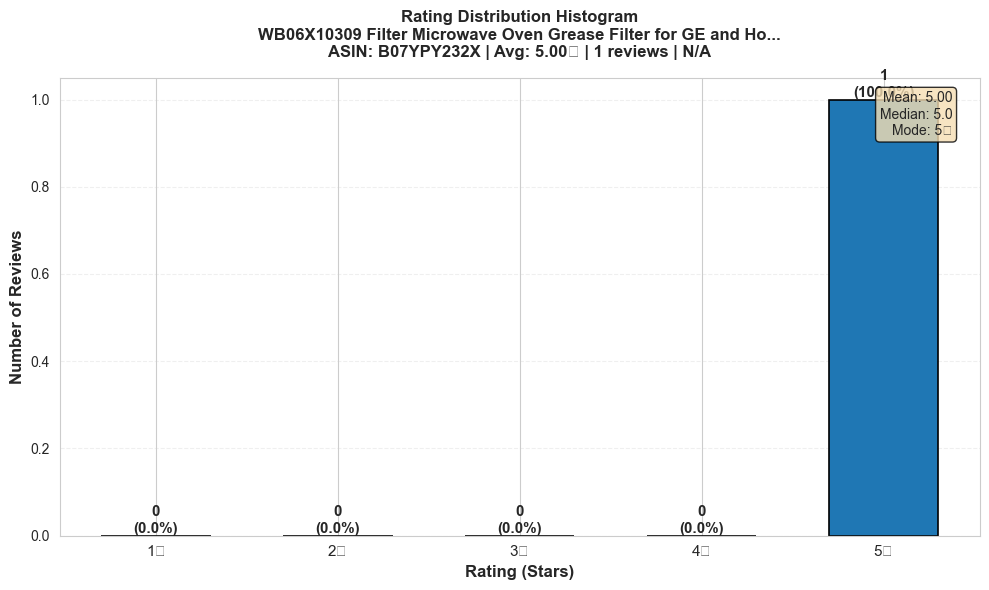


--- Product 2: ATEEZ TREASURE EP.FIN:ALL TO ACTION SPECIAL LIMITE... ---
✓ Saved to: C:\Users\hafil\OneDrive\Documents\SCC 454\scc454_amazon_project\notebooks\docs\product_2_rating_histogram.png


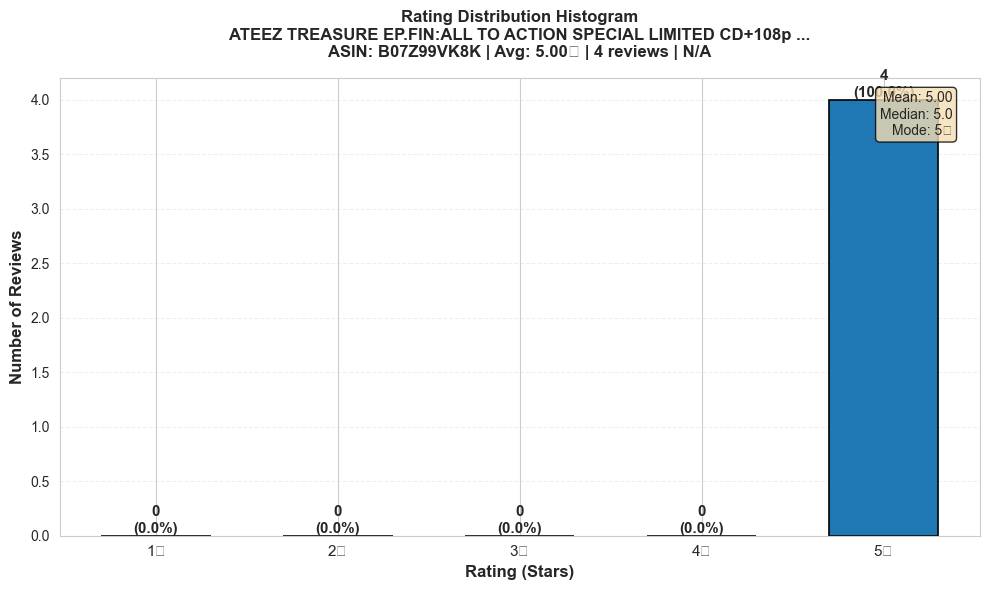


--- Product 3: Bath and Body Works 2 Pack Snowflakes & Cashmere S... ---
✓ Saved to: C:\Users\hafil\OneDrive\Documents\SCC 454\scc454_amazon_project\notebooks\docs\product_3_rating_histogram.png


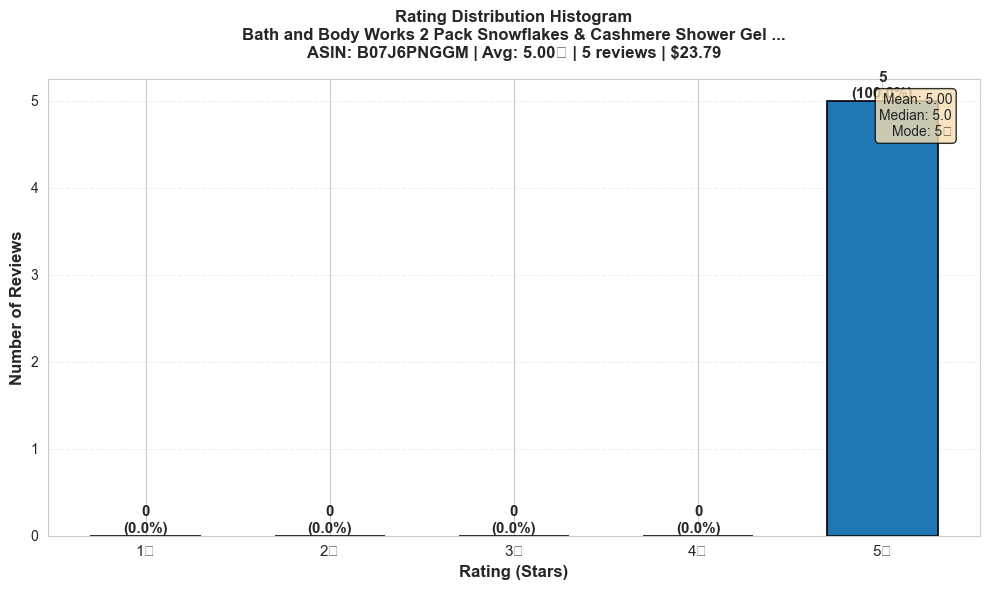


Generating comparison grid for all top 10 products...
✓ Saved comparison grid to: C:\Users\hafil\OneDrive\Documents\SCC 454\scc454_amazon_project\notebooks\docs\top_products_comparison.png


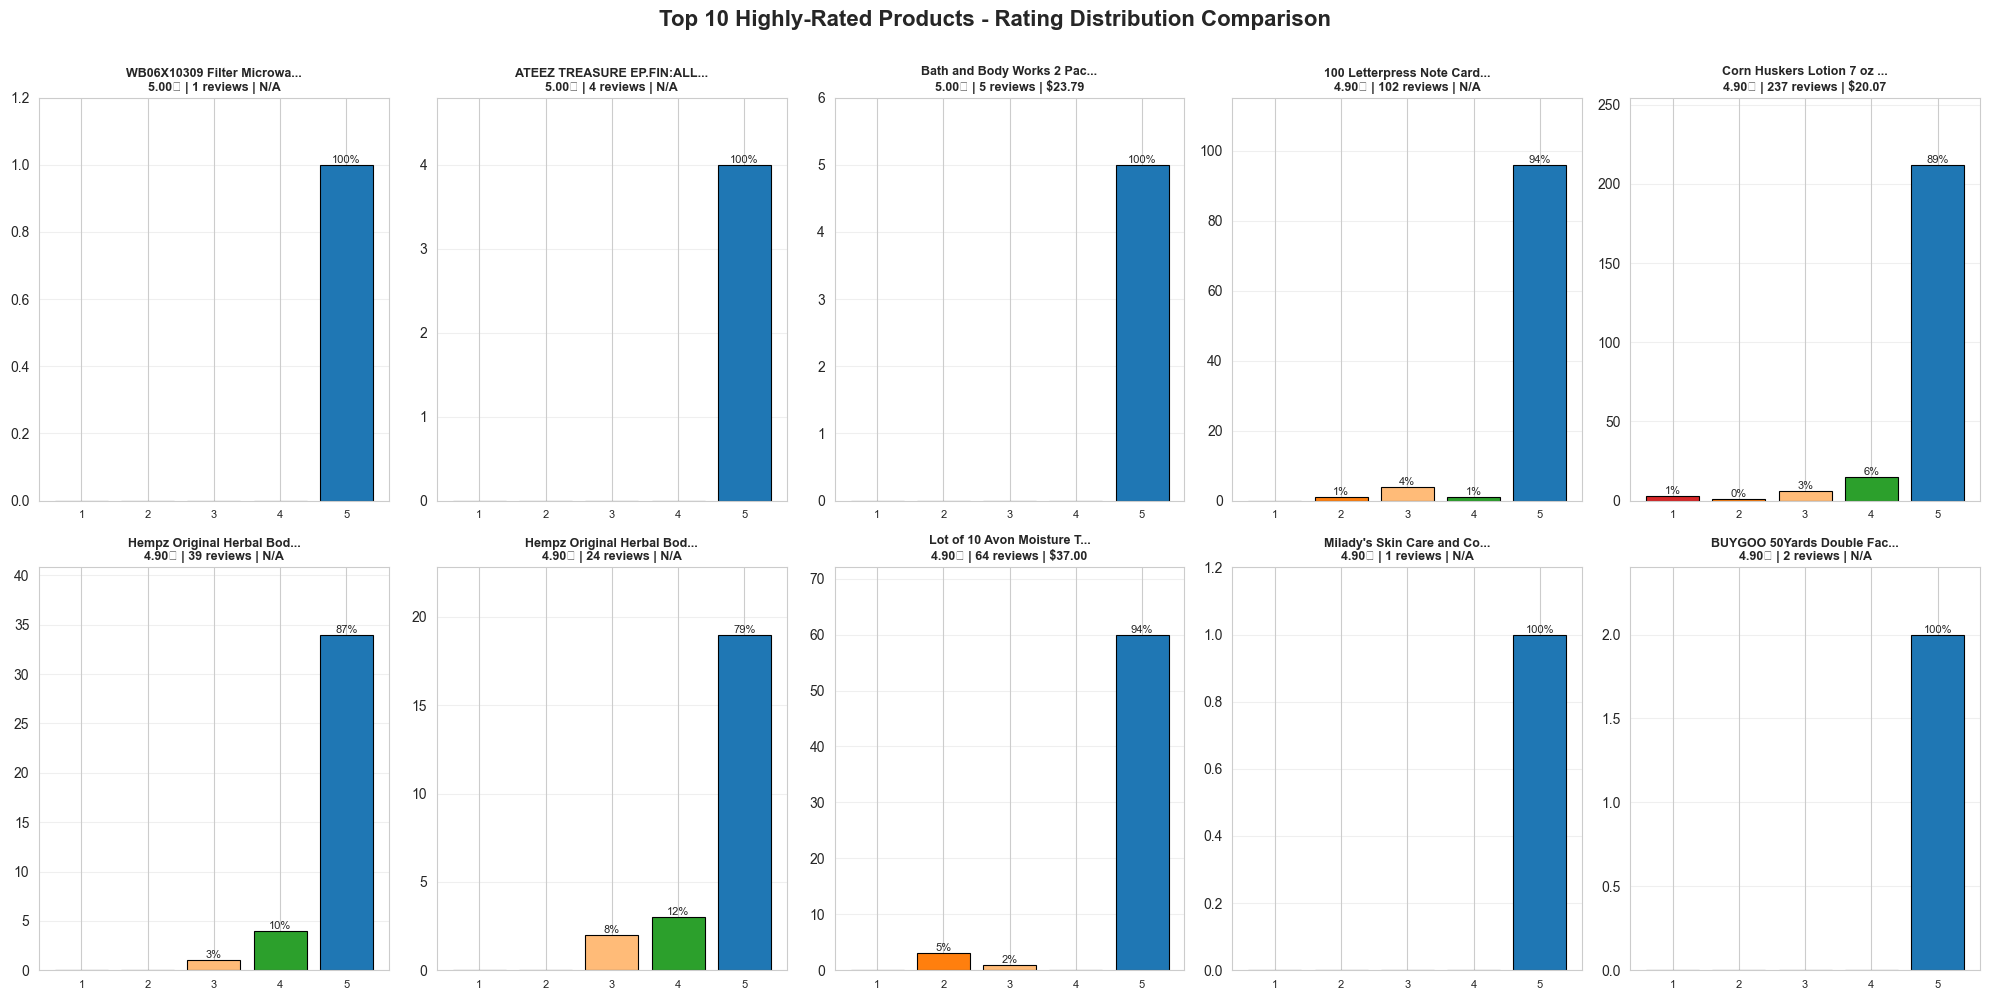


✓ Saved product list to: C:\Users\hafil\OneDrive\Documents\SCC 454\scc454_amazon_project\notebooks\docs\top_rated_products.csv

ANALYSIS COMPLETE!
Generated files:
  - C:\Users\hafil\OneDrive\Documents\SCC 454\scc454_amazon_project\notebooks\docs/product_1_rating_histogram.png
  - C:\Users\hafil\OneDrive\Documents\SCC 454\scc454_amazon_project\notebooks\docs/product_2_rating_histogram.png
  - C:\Users\hafil\OneDrive\Documents\SCC 454\scc454_amazon_project\notebooks\docs/product_3_rating_histogram.png
  - C:\Users\hafil\OneDrive\Documents\SCC 454\scc454_amazon_project\notebooks\docs/top_products_comparison.png
  - C:\Users\hafil\OneDrive\Documents\SCC 454\scc454_amazon_project\notebooks\docs/top_rated_products.csv


In [6]:
# ============================================================================
# BOX: Product Rating Histogram Analysis (FIXED VERSION)
# Shows rating distribution for highly-rated specific products
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def find_highly_rated_products(products_df, reviews_df, min_reviews=50, top_n=10):
    """
    Find highly-rated products with sufficient review volume.
    """
    print(f"Finding top {top_n} highly-rated products (min {min_reviews} reviews)...")
    
    # Filter: high rating + sufficient reviews
    qualified = products_df[
        (products_df['rating_number'] >= min_reviews) & 
        (products_df['average_rating'] >= 4.5)
    ].copy()
    
    # Sort by rating (desc), then by review count (desc)
    qualified = qualified.sort_values(
        by=['average_rating', 'rating_number'], 
        ascending=[False, False]
    )
    
    return qualified.head(top_n)[['parent_asin', 'title', 'average_rating', 
                                   'rating_number', 'price', 'main_category']]

def get_product_rating_distribution(reviews_df, product_asin):
    """Get rating distribution (1-5 stars) for a specific product."""
    product_reviews = reviews_df[reviews_df['parent_asin'] == product_asin]
    rating_counts = product_reviews['rating'].value_counts().sort_index()
    
    # Ensure all ratings 1-5 exist
    all_ratings = pd.Series(0, index=[1, 2, 3, 4, 5])
    for rating, count in rating_counts.items():
        if rating in all_ratings.index:
            all_ratings[rating] = count
    
    return all_ratings, len(product_reviews)

def plot_product_rating_histogram(product_info, rating_dist, total_reviews, save_path=None):
    """
    Create a histogram showing rating distribution for a specific product.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ratings = rating_dist.index.values  # Convert to numpy array
    counts = rating_dist.values
    
    # Color gradient: red (1★) → orange → yellow → light green → blue (5★)
    colors = ['#d62728', '#ff7f0e', '#ffbb78', '#2ca02c', '#1f77b4']
    
    bars = ax.bar(ratings, counts, color=colors, edgecolor='black', linewidth=1.2, width=0.6)
    
    # Add value labels on bars
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        pct = count/total_reviews*100 if total_reviews > 0 else 0
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Title with product info
    title = product_info['title']
    asin = product_info['parent_asin']
    avg_rating = product_info['average_rating']
    price = product_info['price']
    price_str = f"${price:.2f}" if pd.notna(price) else "N/A"
    
    ax.set_title(f'Rating Distribution Histogram\n{title[:60]}{"..." if len(title) > 60 else ""}\n'
                 f'ASIN: {asin} | Avg: {avg_rating:.2f}★ | {total_reviews} reviews | {price_str}',
                 fontsize=12, fontweight='bold', pad=15)
    
    ax.set_xlabel('Rating (Stars)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Reviews', fontsize=12, fontweight='bold')
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xticklabels(['1★', '2★', '3★', '4★', '5★'], fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Statistics box - FIXED VERSION
    mean_rating = avg_rating
    if total_reviews > 0 and counts.sum() > 0:
        # Calculate median properly
        all_values = []
        for r, c in zip(ratings, counts):
            all_values.extend([r] * int(c))
        median_rating = np.median(all_values) if all_values else 0
        mode_rating = ratings[np.argmax(counts)]
    else:
        median_rating = 0
        mode_rating = 0
    
    stats_text = f'Mean: {mean_rating:.2f}\nMedian: {median_rating:.1f}\nMode: {mode_rating:.0f}★'
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black'))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved to: {save_path}")
    
    plt.show()
    plt.close()

def plot_comparison_grid(top_products, reviews_df, save_path=None):
    """
    Create a comparison grid showing all top products side by side.
    """
    fig, axes = plt.subplots(2, 5, figsize=(20, 10))
    axes = axes.flatten()
    
    colors = ['#d62728', '#ff7f0e', '#ffbb78', '#2ca02c', '#1f77b4']
    
    for idx, (_, product) in enumerate(top_products.iterrows()):
        if idx >= 10:
            break
        
        ax = axes[idx]
        
        # Get rating distribution
        rating_dist, total = get_product_rating_distribution(
            reviews_df, product['parent_asin']
        )
        
        ratings = rating_dist.index.values
        counts = rating_dist.values
        
        bars = ax.bar(ratings, counts, color=colors, edgecolor='black', linewidth=0.8)
        
        # Add percentage labels
        for bar, count in zip(bars, counts):
            if count > 0:
                pct = count/total*100
                ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                        f'{pct:.0f}%', ha='center', va='bottom', fontsize=8)
        
        # Truncate title
        title = product['title'][:25] + "..." if len(product['title']) > 25 else product['title']
        price_str = f"${product['price']:.2f}" if pd.notna(product['price']) else "N/A"
        ax.set_title(f'{title}\n{product["average_rating"]:.2f}★ | {total} reviews | {price_str}',
                     fontsize=9, fontweight='bold', pad=5)
        ax.set_xticks([1, 2, 3, 4, 5])
        ax.set_xticklabels(['1', '2', '3', '4', '5'], fontsize=8)
        ax.set_ylim(0, max(counts) * 1.2 if max(counts) > 0 else 10)
        ax.grid(axis='y', alpha=0.3)
    
    plt.suptitle('Top 10 Highly-Rated Products - Rating Distribution Comparison',
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved comparison grid to: {save_path}")
    
    plt.show()
    plt.close()

# ============================================================================
# MAIN EXECUTION
# ============================================================================

print("="*80)
print("PRODUCT RATING HISTOGRAM ANALYSIS")
print("="*80)

# Detect current working directory and set up paths
current_dir = Path.cwd()
print(f"Current working directory: {current_dir}")

# Try multiple possible paths for data
possible_data_paths = [
    current_dir / "data" / "processed",
    current_dir / ".." / "data" / "processed",
    current_dir / "scc454_amazon_project" / "data" / "processed",
    Path("C:/Users/hafil/OneDrive/Documents/SCC 454/scc454_amazon_project/data/processed"),
]

data_dir = None
for path in possible_data_paths:
    if path.exists():
        test_file = path / "All_Beauty_metadata_cleaned.parquet"
        if test_file.exists():
            data_dir = path
            print(f"✓ Found data at: {data_dir}")
            break

if data_dir is None:
    # Try EDA class data
    try:
        if 'eda' in globals() and hasattr(eda, 'meta_df') and hasattr(eda, 'reviews_df'):
            print("✓ Using EDA class data")
            products_df = eda.meta_df
            reviews_df = eda.reviews_df
            data_source = "EDA class"
        else:
            raise NameError("No data found")
    except NameError:
        print("❌ No data source found!")
        raise
else:
    print("\nLoading cleaned data from parquet files...")
    products_df = pd.read_parquet(data_dir / "All_Beauty_metadata_cleaned.parquet")
    reviews_df = pd.read_parquet(data_dir / "All_Beauty_reviews_cleaned.parquet")
    data_source = f"Parquet files ({data_dir})"

print(f"\nData source: {data_source}")
print(f"Products: {len(products_df):,}")
print(f"Reviews: {len(reviews_df):,}")

# Setup output directory
docs_dir = current_dir / "docs"
if not docs_dir.exists():
    docs_dir = current_dir / ".." / "docs"
if not docs_dir.exists():
    docs_dir = Path("C:/Users/hafil/OneDrive/Documents/SCC 454/scc454_amazon_project/docs")

docs_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {docs_dir}")

# Find highly-rated products
top_products = find_highly_rated_products(
    products_df, reviews_df, 
    min_reviews=50,
    top_n=10
)

# Display top products table
print("\n" + "="*80)
print("TOP 10 HIGHLY-RATED PRODUCTS")
print("="*80)

for idx, (_, product) in enumerate(top_products.iterrows(), 1):
    price_str = f"${product['price']:.2f}" if pd.notna(product['price']) else "N/A"
    print(f"\n{idx}. {product['title']}")
    print(f"   ASIN: {product['parent_asin']}")
    print(f"   ⭐ Rating: {product['average_rating']:.2f}/5.0 ({product['rating_number']} reviews)")
    print(f"   💰 Price: {price_str}")
    print(f"   🏷️  Category: {product['main_category']}")

print("\n" + "="*80)

# Generate individual histograms for top 3 products
print("\nGenerating detailed histograms for top 3 products...")

for idx, (_, product) in enumerate(top_products.head(3).iterrows(), 1):
    print(f"\n--- Product {idx}: {product['title'][:50]}... ---")
    
    rating_dist, total_reviews = get_product_rating_distribution(
        reviews_df, product['parent_asin']
    )
    
    save_path = docs_dir / f"product_{idx}_rating_histogram.png"
    plot_product_rating_histogram(product, rating_dist, total_reviews, save_path)

# Generate comparison grid for all 10 products
print("\nGenerating comparison grid for all top 10 products...")
plot_comparison_grid(top_products, reviews_df, docs_dir / "top_products_comparison.png")

# Save to CSV
csv_path = docs_dir / "top_rated_products.csv"
top_products.to_csv(csv_path, index=False)
print(f"\n✓ Saved product list to: {csv_path}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("Generated files:")
for i in range(1, 4):
    print(f"  - {docs_dir}/product_{i}_rating_histogram.png")
print(f"  - {docs_dir}/top_products_comparison.png")
print(f"  - {docs_dir}/top_rated_products.csv")
print("="*80)

LEATHER CONDITIONER PRODUCT SEARCH
✓ Loaded from parquet files

FOUND 10 LEATHER PRODUCT(S)

1. Blackfire High-uv Leather Conditioner 128 Oz.
   ASIN: B005UE60LE
   ⭐ Rating: 5.00/5.0 (1 reviews)
   💰 Price: N/A
   🏷️  Category: All Beauty

2. Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack)
   ASIN: B01CUPMQZE
   ⭐ Rating: 4.80/5.0 (10 reviews)
   💰 Price: N/A
   🏷️  Category: All Beauty

3. Blackfire High-uv Leather Conditioner 16 Oz.
   ASIN: B005QNCIVK
   ⭐ Rating: 4.80/5.0 (6 reviews)
   💰 Price: N/A
   🏷️  Category: All Beauty

4. COBBLER'S CHOICE CO. FINEST QUALITY All-Natural Leather Restorer Conditioner
   ASIN: B09KKXB1SZ
   ⭐ Rating: 4.60/5.0 (544 reviews)
   💰 Price: $18.00
   🏷️  Category: All Beauty

5. Tenderly by URAD Delicate Leather Softener Conditioner w/Applicator 5 oz - Neutral
   ASIN: B0178JZSFC
   ⭐ Rating: 4.50/5.0 (114 reviews)
   💰 Price: $24.90
   🏷️  Category: All Beauty

6. Howard LC0008 Leather Conditioner, 8-Ounce (2-pack)
   ASIN: B01CUPMPZA
   ⭐ Rat

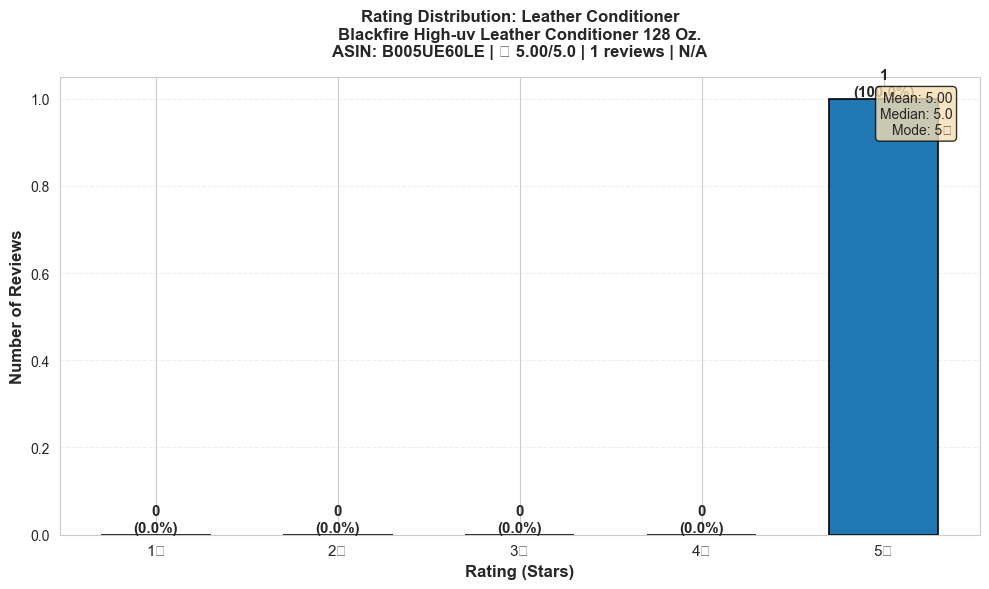


--- Leather Product 2: Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack... ---
✓ Saved to: docs\leather_product_2_rating_histogram.png


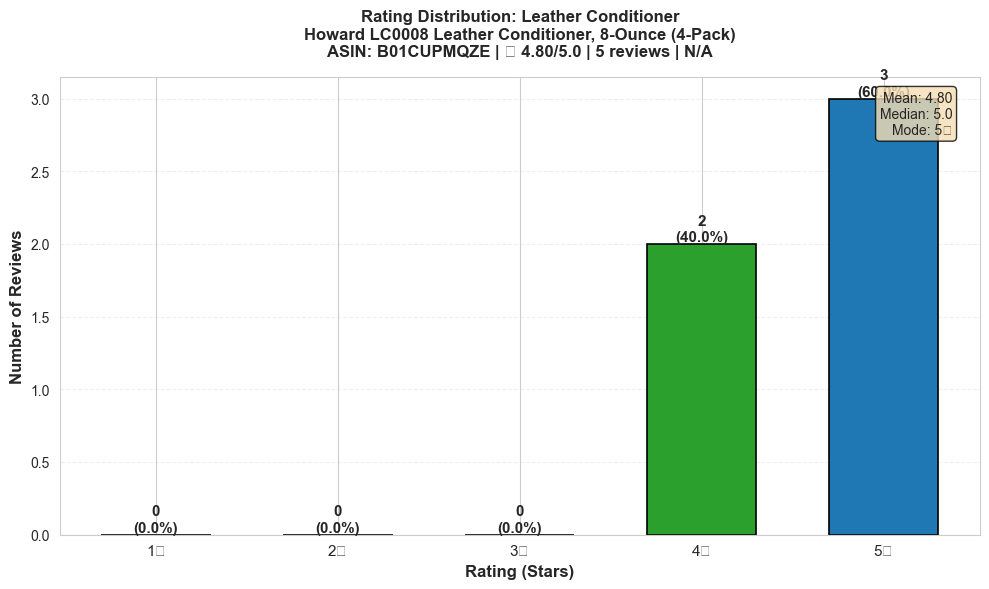


--- Leather Product 3: Blackfire High-uv Leather Conditioner 16 Oz.... ---
✓ Saved to: docs\leather_product_3_rating_histogram.png


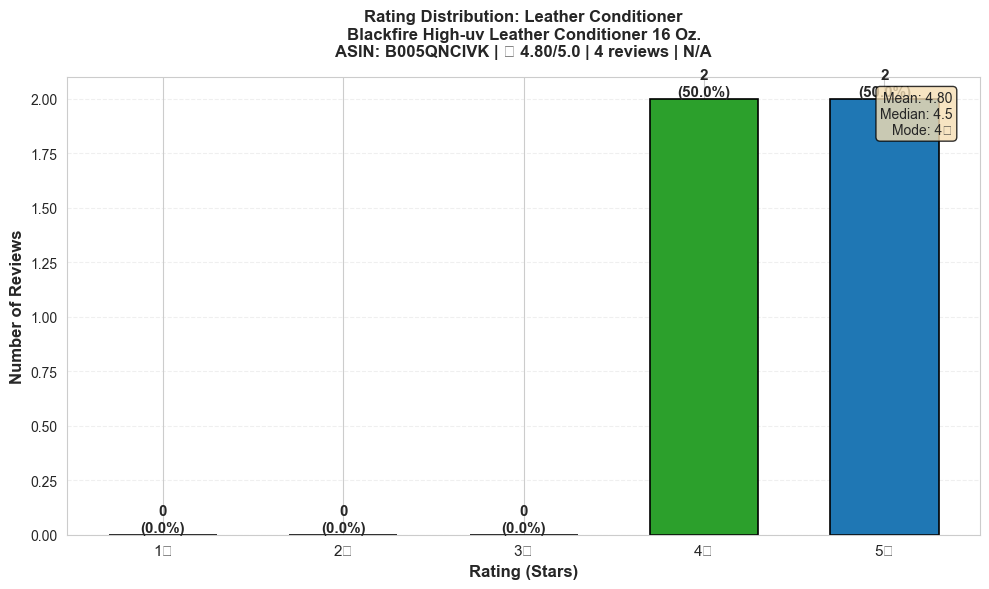


✓ Saved leather product list to: docs\leather_conditioner_products.csv

LEATHER CONDITIONER ANALYSIS COMPLETE


In [7]:
# ============================================================================
# BOX: Leather Conditioner Product Analysis
# Search for leather conditioner products and create rating histograms
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def get_product_rating_distribution(reviews_df, product_asin):
    """Get rating distribution (1-5 stars) for a specific product."""
    product_reviews = reviews_df[reviews_df['parent_asin'] == product_asin]
    rating_counts = product_reviews['rating'].value_counts().sort_index()
    
    # Ensure all ratings 1-5 exist
    all_ratings = pd.Series(0, index=[1, 2, 3, 4, 5])
    for rating, count in rating_counts.items():
        if rating in all_ratings.index:
            all_ratings[rating] = count
    
    return all_ratings, len(product_reviews)

def plot_product_rating_histogram(product_info, rating_dist, total_reviews, save_path=None):
    """Create histogram for a specific product."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ratings = rating_dist.index.values
    counts = rating_dist.values
    
    # Colors: red → orange → yellow → green → blue
    colors = ['#d62728', '#ff7f0e', '#ffbb78', '#2ca02c', '#1f77b4']
    
    bars = ax.bar(ratings, counts, color=colors, edgecolor='black', linewidth=1.2, width=0.6)
    
    # Add value labels
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        pct = count/total_reviews*100 if total_reviews > 0 else 0
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Title
    title = product_info['title']
    asin = product_info['parent_asin']
    avg_rating = product_info['average_rating']
    price = product_info['price']
    price_str = f"${price:.2f}" if pd.notna(price) else "N/A"
    
    ax.set_title(f'Rating Distribution: Leather Conditioner\n{title[:60]}{"..." if len(title) > 60 else ""}\n'
                 f'ASIN: {asin} | ⭐ {avg_rating:.2f}/5.0 | {total_reviews} reviews | {price_str}',
                 fontsize=12, fontweight='bold', pad=15)
    
    ax.set_xlabel('Rating (Stars)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Reviews', fontsize=12, fontweight='bold')
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xticklabels(['1★', '2★', '3★', '4★', '5★'], fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Statistics box
    if total_reviews > 0 and counts.sum() > 0:
        all_values = []
        for r, c in zip(ratings, counts):
            all_values.extend([r] * int(c))
        median_rating = np.median(all_values) if all_values else 0
        mode_rating = ratings[np.argmax(counts)]
    else:
        median_rating = 0
        mode_rating = 0
    
    stats_text = f'Mean: {avg_rating:.2f}\nMedian: {median_rating:.1f}\nMode: {mode_rating:.0f}★'
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black'))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved to: {save_path}")
    
    plt.show()
    plt.close()

# ============================================================================
# MAIN: Search for Leather Conditioner Products
# ============================================================================

print("="*80)
print("LEATHER CONDITIONER PRODUCT SEARCH")
print("="*80)

# Use data from previous cells (eda object or loaded dataframes)
try:
    if 'eda' in globals() and hasattr(eda, 'meta_df'):
        products_df = eda.meta_df
        reviews_df = eda.reviews_df
        print("✓ Using EDA class data")
    else:
        # Try to load from parquet
        data_dir = Path("../data/processed")
        if not data_dir.exists():
            data_dir = Path("data/processed")
        products_df = pd.read_parquet(data_dir / "All_Beauty_metadata_cleaned.parquet")
        reviews_df = pd.read_parquet(data_dir / "All_Beauty_reviews_cleaned.parquet")
        print("✓ Loaded from parquet files")
except Exception as e:
    print(f"❌ Error loading data: {e}")
    raise

# Search for leather conditioner (case insensitive)
search_terms = ['leather', 'conditioner']
mask = products_df['title'].str.contains(search_terms[0], case=False, na=False)
for term in search_terms[1:]:
    mask = mask & products_df['title'].str.contains(term, case=False, na=False)

leather_products = products_df[mask].copy()

# Also search for related terms
if len(leather_products) == 0:
    print("\nNo exact 'leather conditioner' found. Searching for 'leather' products...")
    mask = products_df['title'].str.contains('leather', case=False, na=False)
    leather_products = products_df[mask].copy()

print(f"\n{'='*80}")
print(f"FOUND {len(leather_products)} LEATHER PRODUCT(S)")
print(f"{'='*80}")

# Sort by rating and review count
leather_products = leather_products.sort_values(
    by=['average_rating', 'rating_number'], 
    ascending=[False, False]
)

# Display all found products
for idx, (_, product) in enumerate(leather_products.iterrows(), 1):
    price_str = f"${product['price']:.2f}" if pd.notna(product['price']) else "N/A"
    print(f"\n{idx}. {product['title']}")
    print(f"   ASIN: {product['parent_asin']}")
    print(f"   ⭐ Rating: {product['average_rating']:.2f}/5.0 ({product['rating_number']} reviews)")
    print(f"   💰 Price: {price_str}")
    print(f"   🏷️  Category: {product.get('main_category', 'N/A')}")

# Generate histograms for top 3 leather products (if any found)
if len(leather_products) > 0:
    print(f"\n{'='*80}")
    print("GENERATING RATING HISTOGRAMS FOR LEATHER PRODUCTS")
    print(f"{'='*80}")
    
    # Setup output
    docs_dir = Path("docs")
    docs_dir.mkdir(exist_ok=True)
    
    for idx, (_, product) in enumerate(leather_products.head(3).iterrows(), 1):
        print(f"\n--- Leather Product {idx}: {product['title'][:50]}... ---")
        
        rating_dist, total_reviews = get_product_rating_distribution(
            reviews_df, product['parent_asin']
        )
        
        save_path = docs_dir / f"leather_product_{idx}_rating_histogram.png"
        plot_product_rating_histogram(product, rating_dist, total_reviews, save_path)
    
    # Save list to CSV
    csv_path = docs_dir / "leather_conditioner_products.csv"
    leather_products.to_csv(csv_path, index=False)
    print(f"\n✓ Saved leather product list to: {csv_path}")
else:
    print("\n❌ No leather conditioner products found in the dataset.")
    print("Try searching with different terms or check the 'All Beauty' category scope.")

print(f"\n{'='*80}")
print("LEATHER CONDITIONER ANALYSIS COMPLETE")
print(f"{'='*80}")